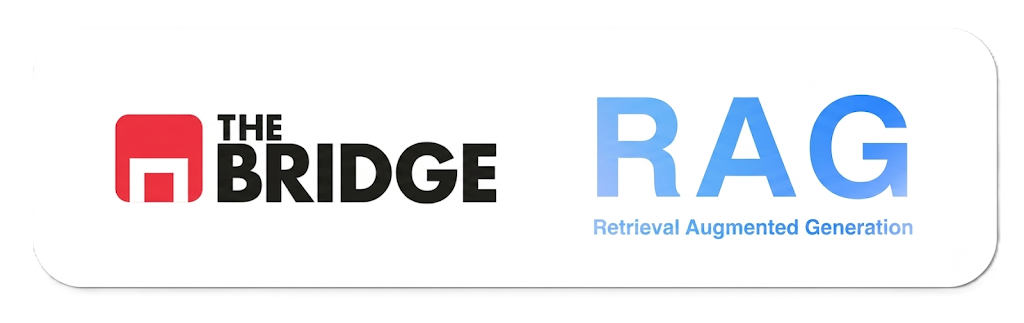

# Embeddings

Un **embedding** convierte texto en una lista de números (vector). Textos con significado parecido → vectores cercanos. En RAG usamos eso para **buscar** el chunk relevante antes de pedirle respuesta al LLM.

### Objetivos

1. Configurar la API de Gemini con el modelo **`gemini-embedding-2`**.
2. Embeddear **una pregunta** y ver la forma del vector (3072 dimensiones por defecto).
3. Embeddear **varios chunks** de la agenda cultural en batch — **un vector por chunk**.

### Requisitos

- **`GEMINI_API_KEY`**: la celda de setup la lee de `.env` o te la pide por prompt (input oculto).

> **Regla de oro:** usa el **mismo modelo** de embedding para indexar chunks y para embeddear la pregunta del usuario (Sprint 9).

### Dependencias

Descomenta la celda siguiente si no tienes instalados `google-genai` (SDK de Gemini) ni `python-dotenv` (lectura opcional de `.env`).

In [ ]:
# %pip install google-genai python-dotenv

### Setup — cliente Gemini

- `load_dotenv()` busca `GEMINI_API_KEY` en un archivo `.env` del directorio actual (opcional).
- Si no hay clave en entorno, `getpass` la pide **sin mostrarla** en pantalla.
- Modelo usado: **`gemini-embedding-2`** → vectores de **3072 dimensiones** por defecto (modelo actual de la familia Gemini).
- No cambies de modelo a mitad del pipeline sin re-embeddear todo el corpus.

> Con `gemini-embedding-2`, pasar varios strings como `contents=["a", "b", "c"]` puede devolver **un solo** embedding agregado. Más abajo usamos `types.Content` para obtener **uno por chunk**.

In [3]:
import getpass
import os

from dotenv import load_dotenv
from google import genai

load_dotenv()  # opcional: lee GEMINI_API_KEY desde .env si existe

if not os.getenv("GEMINI_API_KEY"):
    os.environ["GEMINI_API_KEY"] = getpass.getpass(
        "Pega tu GEMINI_API_KEY (input oculto): "
    )

EMBEDDING_MODEL = "gemini-embedding-2"
client = genai.Client()
print("Cliente OK, modelo:", EMBEDDING_MODEL)

Cliente OK, modelo: gemini-embedding-2


## 1) Embeddear una frase

Empezamos con lo mínimo: **un string → un vector**.

- `embed_content` devuelve `result.embeddings[0].values`: la lista de floats.
- Con `gemini-embedding-2` el vector tiene **3072** componentes por defecto (puedes reducirlo con `output_dimensionality` si necesitas ahorrar almacenamiento).
- No interpretes cada número; importa la **longitud** y que el mismo modelo siempre produce vectores del mismo tamaño.
- En Sprint 9 embeddearás la **pregunta del usuario** con la misma llamada.

In [4]:
texto = "¿Hay eventos culturales gratuitos en Madrid este verano?"
result = client.models.embed_content(model=EMBEDDING_MODEL, contents=texto)
vector = list(result.embeddings[0].values)
print(f"Dimensiones: {len(vector)}")
print(f"Primeros 5 valores: {vector[:5]}")

Dimensiones: 3072
Primeros 5 valores: [-0.0008114631, -0.020813266, -0.0003976301, -0.0070459396, 0.0050842846]


**Salida esperada:** `Dimensiones: 3072` y cinco floats pequeños (positivos y negativos). Si la API falla, revisa la clave y que tengas cuota en Google AI Studio.

## 2) Embeddear varios chunks (batch)

En producción los chunks salen del pipeline de ingesta. Aquí definimos **tres fragmentos de ejemplo** de lo que saldría sobre la agenda cultural de Madrid:

| Chunk | Origen | Contenido |
|-------|--------|-----------|
| 0 | FAQ | Campo GRATUITO del CSV |
| 1 | CSV | Evento concreto (cine gratis en Hortaleza) |
| 2 | Guía | Tipos de actividad frecuentes |

Cada entrada tiene `text` (lo que se embeddea) y `metadata` (procedencia; **no** entra en el vector, viaja aparte).

La celda siguiente **solo muestra** los chunks. La siguiente los embeddea con **`types.Content`** — obligatorio con `gemini-embedding-2` para obtener un vector por chunk.

In [5]:
chunks_demo = [
    {
        "text": (
            "No. Cada fila del CSV incluye el campo GRATUITO: "
            "1 → actividad gratuita, 0 → puede tener precio o requerir entrada."
        ),
        "metadata": {"source": "data/faq_agenda_cultural.md", "chunk_index": 0},
    },
    {
        "text": (
            "Evento: 10 vidas\n"
            "Actividad: Cine de verano en Hortaleza\n"
            "Lugar: Parque de Villa Rosa-Paco Caño\n"
            "Distrito: HORTALEZA\n"
            "Gratuito: sí"
        ),
        "metadata": {
            "source": "data/206974-4-agenda-eventos-culturales-100-csv.csv",
            "tipo": "agenda_evento",
            "distrito": "HORTALEZA",
            "chunk_index": 1,
        },
    },
    {
        "text": (
            "## Tipos de actividad frecuentes\n\n"
            "- Cine de verano al aire libre en distintos distritos\n"
            "- Exposiciones en centros culturales y museos\n"
            "- Itinerarios guiados (El Retiro, Casa de Campo)\n"
            "- Actividades infantiles y familiares\n"
            "- Conciertos y festivales en espacios municipales"
        ),
        "metadata": {"source": "data/guia_agenda_cultural.txt", "chunk_index": 2},
    },
]

print(f"Chunks a embeddear: {len(chunks_demo)}\n")
for i, chunk in enumerate(chunks_demo):
    print(f"--- Chunk {i} ---")
    print(chunk["text"][:120], "..." if len(chunk["text"]) > 120 else "")
    print("Metadata:", chunk["metadata"], "\n")

textos = [c["text"] for c in chunks_demo]

Chunks a embeddear: 3

--- Chunk 0 ---
No. Cada fila del CSV incluye el campo GRATUITO: 1 → actividad gratuita, 0 → puede tener precio o requerir entrada. 
Metadata: {'source': 'data/faq_agenda_cultural.md', 'chunk_index': 0} 

--- Chunk 1 ---
Evento: 10 vidas
Actividad: Cine de verano en Hortaleza
Lugar: Parque de Villa Rosa-Paco Caño
Distrito: HORTALEZA
Gratui ...
Metadata: {'source': 'data/206974-4-agenda-eventos-culturales-100-csv.csv', 'tipo': 'agenda_evento', 'distrito': 'HORTALEZA', 'chunk_index': 1} 

--- Chunk 2 ---
## Tipos de actividad frecuentes

- Cine de verano al aire libre en distintos distritos
- Exposiciones en centros cultur ...
Metadata: {'source': 'data/guia_agenda_cultural.txt', 'chunk_index': 2} 



### Batch — un embedding por chunk

Con **`gemini-embedding-2`**, envolvemos cada texto en un `types.Content` separado. Si pasas solo `contents=["texto1", "texto2", ...]`, el modelo los trata como **partes de un mismo documento** y devuelve **un único** embedding agregado.

Comprueba al final que `Embeddings recibidos: 3` y que los tres tienen **3072** dimensiones.

In [7]:
from google.genai import types

# Un Content por texto → un embedding por chunk (no uno agregado)
contents = [types.Content(parts=[types.Part(text=t)]) for t in textos]

result = client.models.embed_content(model=EMBEDDING_MODEL, contents=contents)

print(f"Embeddings recibidos: {len(result.embeddings)} (esperados: {len(textos)})\n")
for i, emb in enumerate(result.embeddings):
    v = list(emb.values)
    print(f"Chunk {i}: {len(v)} dims, preview {v[:3]}...")

Embeddings recibidos: 3 (esperados: 3)

Chunk 0: 3072 dims, preview [-0.02467909, -0.01651482, 0.0062639695]...
Chunk 1: 3072 dims, preview [-0.012441496, -0.026445571, 0.011283006]...
Chunk 2: 3072 dims, preview [-0.028974637, -0.032289673, -0.017724942]...


**Salida esperada:** `Embeddings recibidos: 3 (esperados: 3)` y debajo **tres** líneas `Chunk 0`, `Chunk 1` y `Chunk 2`, cada una con **3072 dims**.

Si solo ves **una** línea, no has usado `types.Content` (celda anterior) o no has vuelto a ejecutar el setup y las celdas en orden.

**Qué falta por hacer:** arriba embeddeamos la pregunta *«¿Hay eventos culturales gratuitos en Madrid este verano?»* y aquí los tres fragmentos de la agenda, pero **aún no los hemos comparado** entre ellos. En un RAG completo, el siguiente paso sería calcular la similitud del coseno entre el vector de la pregunta y el de cada chunk para elegir el más relevante. Este será nuestro siguiente tema a estudiar.

En Sprint 9 utilizaremos ChromaDB para recuperar los chunks más relevantes de nuestra base de datos vectorial durante la fase de retrieval.